
# Project : UrbanPulse – City Operations Intelligence

Civic operations analytics on city service requests (311 style): response times, SLA breaches, hotspots, a breach prediction model, a volume forecast and an AI briefing for city managers.

## What this notebook does
- Loads real NYC 311 data sampled across 12 months (24 days), plus true daily ticket volumes from the city's open data API. If the internet call fails, a realistic sample is made instead
- Finds slow categories and areas and checks them against a fixed SLA threshold
- Ranks hotspots (area + category combinations)
- Trains a model to predict slow tickets and compares it with a category-only baseline
- Forecasts the next 4 weeks of ticket volume with a simple trend line
- Uses Groq AI to write a short operations briefing

## How to run
1. Upload this file to Google Colab (or open it from Drive)
2. Runtime → Run all, or run each cell one by one
3. If a step fails, run the cell again, then restart the runtime once and run again
4. Real data note: response-time numbers come from a sample of 24 days (a few hundred tickets per 8-hour window), so use them as rates and medians, not as total counts. Ticket volumes come from a separate full-count query.

## Step 1: Install libraries

In [1]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn openai requests

## Step 2: Connect to Groq (the AI part)
Paste your Groq API key when it asks. The key is hidden while you type.

In [2]:
import time
from getpass import getpass
from openai import OpenAI

GROQ_KEY = getpass("Paste your Groq API key: ")
client = OpenAI(api_key=GROQ_KEY, base_url="https://api.groq.com/openai/v1")
MODEL = "openai/gpt-oss-120b"

def ask_llm(question, system="You are a helpful analyst.", model=MODEL):
    for tries in range(3):
        try:
            r = client.chat.completions.create(
                model=model,
                messages=[{"role": "system", "content": system}, {"role": "user", "content": question}],
                max_tokens=1500,
                temperature=0.3,
            )
            return r.choices[0].message.content
        except Exception as e:
            print("llm error, trying again:", str(e)[:100])
            time.sleep(5)
    return "LLM not available right now."

print(ask_llm("Say hi in five words."))

Paste your Groq API key: ··········
Hey there, how are you?


## Step 3: Load the data
The real data is a sample spread over 12 months so seasons and weekdays are covered. Tickets from the last 2.5 months are skipped because many of them are still open, and open tickets would make the response times look faster than they are.

In [3]:
import os, io, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
warnings.filterwarnings("ignore")
np.random.seed(42)
sns.set_style("whitegrid")

def make_fake_data(n=9000):
    cats = ["Noise", "Pothole", "Water Leak", "Garbage", "Street Light", "Illegal Parking", "Tree Fall", "Sewage"]
    areas = ["Central", "North", "South", "East", "West", "Harbor", "Old Town", "Airport Zone"]
    base_hours = {"Noise": 6, "Pothole": 70, "Water Leak": 20, "Garbage": 30, "Street Light": 55,
                  "Illegal Parking": 8, "Tree Fall": 26, "Sewage": 40}
    area_slow = {"Central": 0.8, "North": 1.0, "South": 1.1, "East": 1.3, "West": 1.0,
                 "Harbor": 1.5, "Old Town": 1.2, "Airport Zone": 0.9}
    dates = pd.to_datetime("2025-01-01") + pd.to_timedelta(np.random.randint(0, 365 * 24, n), unit="h")
    category = np.random.choice(cats, n, p=[0.18, 0.12, 0.1, 0.18, 0.1, 0.14, 0.08, 0.10])
    area = np.random.choice(areas, n)
    hours = []
    for c, a, d in zip(category, area, dates):
        h = base_hours[c] * area_slow[a] * np.random.lognormal(0, 0.6)
        if d.dayofweek >= 5:
            h = h * 1.3
        if d.month in [7, 8]:
            h = h * 1.25
        hours.append(h)
    df = pd.DataFrame({"date": dates, "category": category, "area": area, "response_hours": hours})
    df["status"] = "Closed"
    open_idx = np.random.choice(n, int(n * 0.06), replace=False)
    df.loc[open_idx, "status"] = "Open"
    df.loc[open_idx, "response_hours"] = np.nan
    return df

URL = "https://data.cityofnewyork.us/resource/erm2-nwe9.csv"

def load_real_311():
    today = pd.Timestamp.today().normalize()
    months = pd.date_range(end=today - pd.Timedelta(days=75), periods=12, freq="MS")
    frames = []
    first = True
    for m in months:
        for day_offset in [6, 20]:
            day = m + pd.Timedelta(days=day_offset)
            for start_hour in [0, 8, 16]:
                a = (day + pd.Timedelta(hours=start_hour)).strftime("%Y-%m-%dT%H:%M:%S")
                b = (day + pd.Timedelta(hours=start_hour + 8) - pd.Timedelta(seconds=1)).strftime("%Y-%m-%dT%H:%M:%S")
                params = {"$select": "created_date,closed_date,complaint_type,borough,status",
                          "$where": "created_date between '" + a + "' and '" + b + "'",
                          "$order": "created_date", "$limit": 300, "$offset": int(np.random.randint(0, 1200))}
                try:
                    resp = requests.get(URL, params=params, timeout=25)
                    part = pd.read_csv(io.StringIO(resp.text))
                    if "created_date" in part.columns and len(part) > 0:
                        frames.append(part)
                except Exception as e:
                    if first:
                        raise
                first = False
                time.sleep(0.15)
    if len(frames) == 0:
        raise ValueError("no rows came back")
    raw = pd.concat(frames, ignore_index=True)
    raw["created_date"] = pd.to_datetime(raw["created_date"])
    raw["closed_date"] = pd.to_datetime(raw["closed_date"])
    df = pd.DataFrame({
        "date": raw["created_date"], "category": raw["complaint_type"], "area": raw["borough"],
        "response_hours": (raw["closed_date"] - raw["created_date"]).dt.total_seconds() / 3600,
        "status": raw["status"]})
    df = df.dropna(subset=["date", "category", "area"])
    df = df[df["area"] != "Unspecified"]
    top_cats = df["category"].value_counts().head(8).index
    df = df[df["category"].isin(top_cats)].reset_index(drop=True)
    if len(df) < 3000:
        raise ValueError("too few rows")
    vol_params = {"$select": "date_trunc_ymd(created_date) as day, count(*) as tickets",
                  "$where": "created_date between '" + months[0].strftime("%Y-%m-%dT00:00:00") + "' and '" + (months[-1] + pd.Timedelta(days=31)).strftime("%Y-%m-%dT00:00:00") + "'",
                  "$group": "day", "$order": "day", "$limit": 1000}
    daily = None
    try:
        v = pd.read_csv(io.StringIO(requests.get(URL, params=vol_params, timeout=90).text))
        v["day"] = pd.to_datetime(v["day"])
        daily = v.set_index("day")["tickets"].astype(float)
    except Exception as e:
        print("Daily volume query failed (forecast will be skipped):", str(e)[:80])
    return df, daily

try:
    df, daily_volume = load_real_311()
    data_source = "real NYC 311 sample (24 days over 12 months)"
except Exception as e:
    print("Real data not loaded, using sample data instead:", str(e)[:80])
    df = make_fake_data()
    daily_volume = df.set_index("date").resample("D").size().astype(float)
    data_source = "made-up sample data"

print("Data source:", data_source)
print(df.shape, "| days sampled:", df["date"].dt.normalize().nunique())
df.head()

Data source: real NYC 311 sample (24 days over 12 months)
(11678, 5) | days sampled: 24


,date,category,area,response_hours,status
0,2025-08-07 07:26:09,Blocked Driveway,BROOKLYN,1.949444,Closed
1,2025-08-07 07:26:40,Noise - Residential,MANHATTAN,8.175278,Closed
2,2025-08-07 07:27:38,Blocked Driveway,BRONX,6.068611,Closed
3,2025-08-07 07:28:01,Illegal Parking,BROOKLYN,6.232222,Closed
4,2025-08-07 07:28:10,Illegal Parking,BROOKLYN,0.640000,Closed


## Step 4: Clean the data and set the SLA
The SLA here is a fixed threshold chosen for this analysis. It is **not** an official city target. If almost nothing or almost everything breaches 72 hours, the notebook uses the 75th percentile instead and says so loudly.

In [4]:
df["date"] = pd.to_datetime(df["date"])
df = df[df["response_hours"].isna() | (df["response_hours"] >= 0)].copy()
cap = df["response_hours"].quantile(0.99)
df["response_hours"] = df["response_hours"].clip(upper=cap)
df["month"] = df["date"].dt.to_period("M").astype(str)
df["weekday"] = df["date"].dt.dayofweek
df["hour"] = df["date"].dt.hour

closed = df.dropna(subset=["response_hours"]).copy()
SLA_HOURS = 72
closed["breach"] = (closed["response_hours"] > SLA_HOURS).astype(int)
share = closed["breach"].mean()
if share < 0.05 or share > 0.6:
    SLA_HOURS = float(closed["response_hours"].quantile(0.75))
    closed["breach"] = (closed["response_hours"] > SLA_HOURS).astype(int)
    print("WARNING: 72 hours does not split this data well. The SLA is now the 75th percentile (" + str(round(SLA_HOURS, 1)) + " hours),")
    print("so about 25% of tickets are 'slow' by construction. This is an analysis threshold, not an official target.\n")

print("tickets in sample:", len(df))
print("closed tickets:", len(closed), "(" + str(round(len(closed) / len(df) * 100, 1)) + "% of the sample)")
print("SLA hours used:", round(SLA_HOURS, 1))
print("share of closed tickets slower than the SLA:", round(closed["breach"].mean() * 100, 1), "%")

tickets in sample: 11678
closed tickets: 11545 (98.9% of the sample)
SLA hours used: 72
share of closed tickets slower than the SLA: 9.4 %


## Step 5: Which categories and areas are slow?

                         tickets  median_hours  breach_rate
category                                                   
UNSANITARY CONDITION         631        242.92         0.87
Street Condition             579         41.29         0.35
HEAT/HOT WATER              1920         39.13         0.15
Dirty Condition              417         25.60         0.13
Blocked Driveway            1073          1.47         0.00
Illegal Parking             3512          1.46         0.00
Noise - Residential         2568          1.21         0.00
Noise - Street/Sidewalk      845          1.12         0.00

               tickets  median_hours  breach_rate
area                                             
MANHATTAN         1885          2.50         0.12
STATEN ISLAND      282          3.27         0.11
BROOKLYN          3702          2.47         0.10
BRONX             2804          3.64         0.09
QUEENS            2872          2.13         0.07

Ticket counts are sample sizes, not real city to

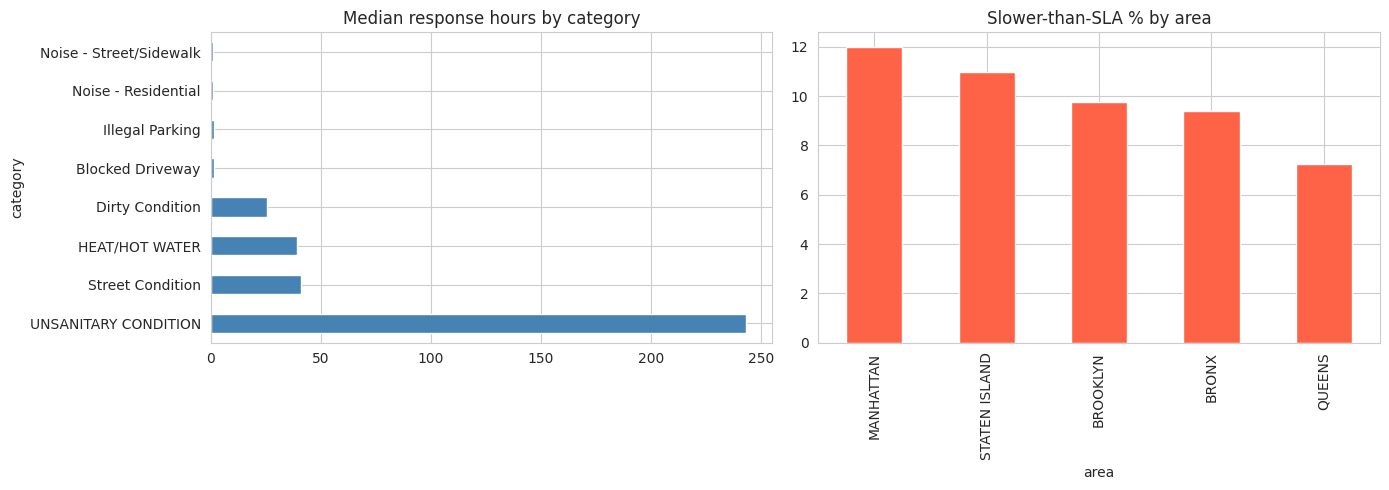

In [5]:
cat_stats = closed.groupby("category").agg(tickets=("breach", "size"),
                                            median_hours=("response_hours", "median"),
                                            breach_rate=("breach", "mean")).sort_values("median_hours", ascending=False)
area_stats = closed.groupby("area").agg(tickets=("breach", "size"),
                                         median_hours=("response_hours", "median"),
                                         breach_rate=("breach", "mean")).sort_values("breach_rate", ascending=False)
print(cat_stats.round(2))
print()
print(area_stats.round(2))
print("\nTicket counts are sample sizes, not real city totals.")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
cat_stats["median_hours"].plot(kind="barh", ax=ax[0], color="steelblue")
ax[0].set_title("Median response hours by category")
(area_stats["breach_rate"] * 100).plot(kind="bar", ax=ax[1], color="tomato")
ax[1].set_title("Slower-than-SLA % by area")
plt.tight_layout()
plt.show()

## Step 6: Time patterns (rates only)
The sample has a fixed size per time window, so we look at rates and medians here, never at ticket counts.

         median_hours  breach_rate  tickets
month                                      
2025-08          2.06         0.15      531
2025-09          1.08         0.04     1116
2025-10          2.59         0.09      899
2025-11          3.11         0.11     1049
2025-12          3.36         0.08     1215
2026-01          7.72         0.07      989
2026-02          3.41         0.16     1118
2026-03          2.81         0.10     1057
2026-04          3.45         0.09      995
2026-05          2.55         0.10      781
2026-06          1.74         0.04     1015
2026-07          2.41         0.13      780

     breach_rate  tickets
Tue         0.10     2674
Wed         0.07      989
Thu         0.12     1312
Fri         0.11     1049
Sat         0.13     2175
Sun         0.06     3346

             breach_rate  tickets
time_of_day                      
00-08               0.05     4663
08-16               0.14     3256
16-24               0.11     3626


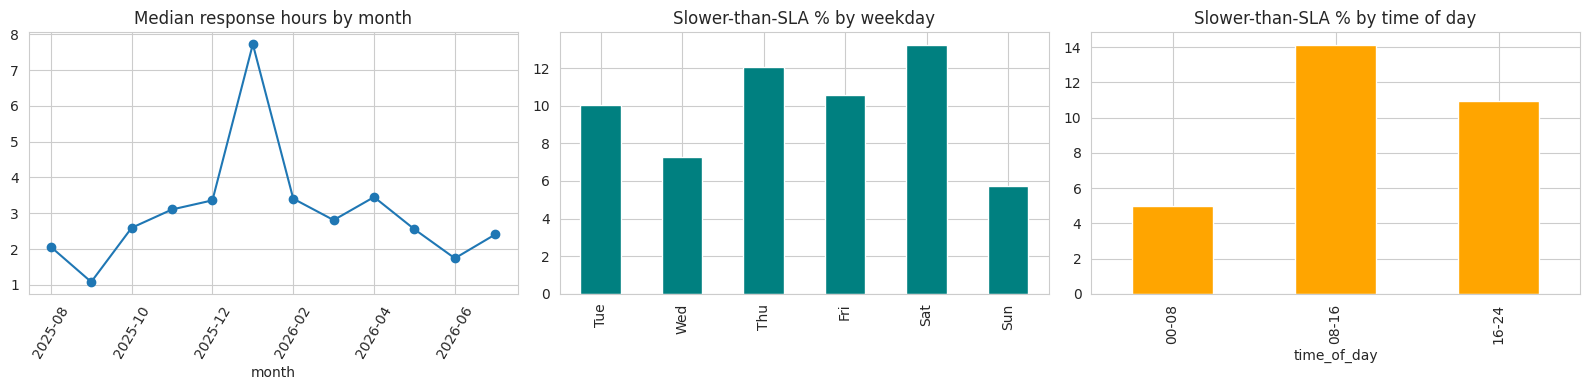

In [6]:
weekday_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
by_month = closed.groupby("month").agg(median_hours=("response_hours", "median"), breach_rate=("breach", "mean"), tickets=("breach", "size"))
by_day = closed.groupby("weekday").agg(breach_rate=("breach", "mean"), tickets=("breach", "size"))
by_day.index = [weekday_names[i] for i in by_day.index]
closed["time_of_day"] = pd.cut(closed["hour"], bins=[-1, 7, 15, 23], labels=["00-08", "08-16", "16-24"])
by_time = closed.groupby("time_of_day").agg(breach_rate=("breach", "mean"), tickets=("breach", "size"))

print(by_month.round(2))
print()
print(by_day.round(2))
print()
print(by_time.round(2))

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
by_month["median_hours"].plot(ax=ax[0], marker="o")
ax[0].set_title("Median response hours by month")
ax[0].tick_params(axis="x", rotation=60)
(by_day["breach_rate"] * 100).plot(kind="bar", ax=ax[1], color="teal")
ax[1].set_title("Slower-than-SLA % by weekday")
(by_time["breach_rate"] * 100).plot(kind="bar", ax=ax[2], color="orange")
ax[2].set_title("Slower-than-SLA % by time of day")
plt.tight_layout()
plt.show()

## Step 7: Hotspot ranking
Hotspot = area + category combinations with enough tickets AND a high slow-ticket rate.

In [7]:
hot = closed.groupby(["area", "category"]).agg(tickets=("breach", "size"),
                                                breach_rate=("breach", "mean"),
                                                median_hours=("response_hours", "median")).reset_index()
hot = hot[hot["tickets"] >= 20].copy()
hot["hotspot_score"] = hot["breach_rate"] * np.log1p(hot["tickets"])
hot = hot.sort_values("hotspot_score", ascending=False).reset_index(drop=True)
print(hot.head(10).round(2))

            area              category  tickets  breach_rate  median_hours  \
0          BRONX  UNSANITARY CONDITION      211         0.89        251.80   
1      MANHATTAN  UNSANITARY CONDITION      142         0.91        350.08   
2       BROOKLYN  UNSANITARY CONDITION      189         0.81        200.22   
3         QUEENS  UNSANITARY CONDITION       77         0.90        220.47   
4      MANHATTAN      Street Condition       88         0.45         48.96   
5       BROOKLYN      Street Condition      146         0.40         43.05   
6         QUEENS      Street Condition      231         0.31         25.62   
7       BROOKLYN        HEAT/HOT WATER      571         0.22         43.02   
8  STATEN ISLAND      Street Condition       47         0.30         24.21   
9         QUEENS        HEAT/HOT WATER      261         0.21         47.43   

   hotspot_score  
0           4.75  
1           4.51  
2           4.28  
3           3.90  
4           2.04  
5           1.98  
6       

## Step 8: Predict slow tickets
A model is only useful if it beats a simple rule. The baseline here just uses the average slow rate of each category.

majority-class accuracy: 0.906
model accuracy: 0.946
category-only baseline AUC: 0.946
model AUC: 0.967

If the two AUC numbers are close, the category alone explains most of the delay and area/time add little.


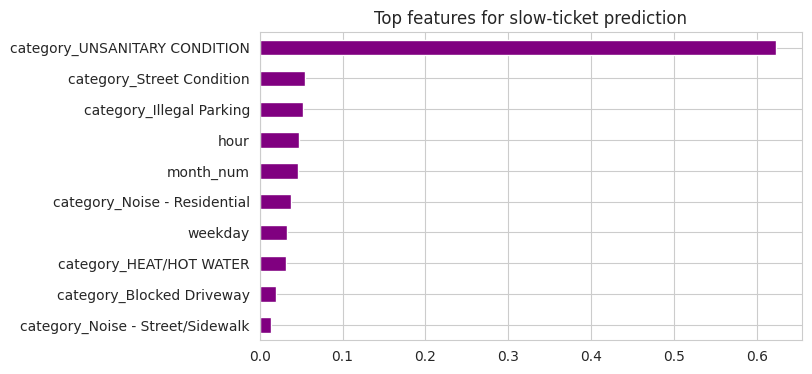

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score

X = pd.get_dummies(closed[["category", "area"]])
X["month_num"] = closed["date"].dt.month.values
X["weekday"] = closed["weekday"].values
X["hour"] = closed["hour"].values
y = closed["breach"]

X_train, X_test, y_train, y_test, cat_train, cat_test = train_test_split(X, y, closed["category"], test_size=0.25, random_state=42, stratify=y)
model = RandomForestClassifier(n_estimators=150, max_depth=8, random_state=42)
model.fit(X_train, y_train)
prob = model.predict_proba(X_test)[:, 1]

cat_rate = y_train.groupby(cat_train).mean()
baseline_prob = cat_test.map(cat_rate).fillna(y_train.mean()).values

print("majority-class accuracy:", round(max(y_test.mean(), 1 - y_test.mean()), 3))
print("model accuracy:", round(accuracy_score(y_test, (prob > 0.5).astype(int)), 3))
print("category-only baseline AUC:", round(roc_auc_score(y_test, baseline_prob), 3))
print("model AUC:", round(roc_auc_score(y_test, prob), 3))
print("\nIf the two AUC numbers are close, the category alone explains most of the delay and area/time add little.")

imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
imp.sort_values().plot(kind="barh", figsize=(7, 4), color="purple")
plt.title("Top features for slow-ticket prediction")
plt.show()

## Step 9: Volume forecast (simple trend line)
Volumes come from the full-count daily query, not from the sample. This is a straight trend line, not a seasonal model, so it will miss yearly cycles.

weeks used: 26 | trend: -367 tickets per week, per week
next 4 weeks forecast: [73198. 72831. 72464. 72096.]


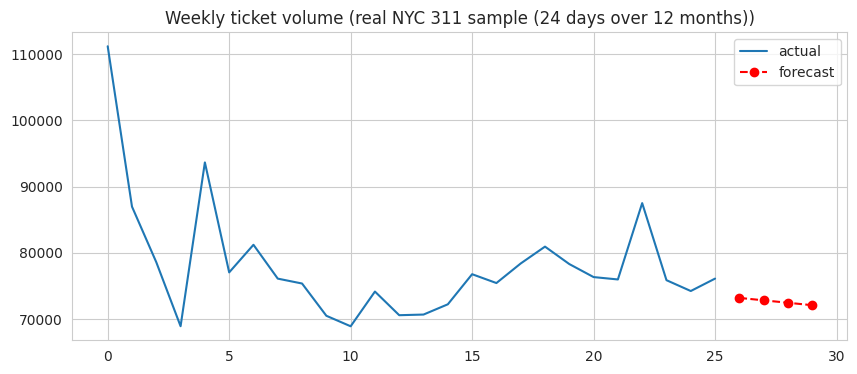

In [9]:
from sklearn.linear_model import LinearRegression

future_pred = None
if daily_volume is not None and len(daily_volume) > 60:
    weekly = daily_volume.resample("W").sum()
    weekly = weekly.iloc[1:-1].tail(26)
    x_week = np.arange(len(weekly)).reshape(-1, 1)
    lr = LinearRegression().fit(x_week, weekly.values)
    future_x = np.arange(len(weekly), len(weekly) + 4).reshape(-1, 1)
    future_pred = lr.predict(future_x)
    print("weeks used:", len(weekly), "| trend:", round(lr.coef_[0]), "tickets per week, per week")
    print("next 4 weeks forecast:", future_pred.round(0))
    plt.figure(figsize=(10, 4))
    plt.plot(range(len(weekly)), weekly.values, label="actual")
    plt.plot(range(len(weekly), len(weekly) + 4), future_pred, "r--o", label="forecast")
    plt.title("Weekly ticket volume (" + data_source + ")")
    plt.legend()
    plt.show()
else:
    print("No daily volume data available, forecast skipped.")

## Step 10: AI operations briefing (Groq)

In [10]:
worst_cat = cat_stats.index[0]
worst_area = area_stats.index[0]
top_hot = hot.head(3)
forecast_text = future_pred.round(0).tolist() if future_pred is not None else "not available"
summary = f"""
Data source: {data_source}
Tickets in sample: {len(df)}; closed tickets analysed: {len(closed)}
SLA threshold used: {SLA_HOURS:.1f} hours. This is an analyst-chosen threshold, NOT an official city target.
Share of closed tickets slower than that threshold: {closed['breach'].mean()*100:.1f}%
Slowest category by median: {worst_cat} (median {cat_stats.loc[worst_cat, 'median_hours']:.1f} hours)
Area with highest slow-ticket rate: {worst_area} ({area_stats.loc[worst_area, 'breach_rate']*100:.1f}%)
Top hotspots: {top_hot[['area','category','breach_rate','tickets']].round(2).to_dict('records')}
Weekly volume forecast (simple trend line, full-count data): {forecast_text}
Slow-ticket model AUC: {roc_auc_score(y_test, prob):.2f} vs category-only baseline {roc_auc_score(y_test, baseline_prob):.2f}
"""
briefing = ask_llm("Write a short operations briefing (3 short paragraphs and 3 action items) for a city commissioner using only these numbers. Say clearly that the SLA threshold is an analysis threshold and that response times come from a sample.\n" + summary,
                   system="You are a city operations analyst. Do not invent numbers or targets.")
print(briefing)

**Operations Briefing – 311 Service Performance (Sample of 24 days, 12 months)**  

Our analysis of 11,678 tickets (11,545 closed) shows that 9.4 % of closed requests exceeded the 72‑hour threshold we use for analytical purposes only; this is not an official city SLA. The response‑time figures are drawn from the sample and should be interpreted as indicative rather than definitive. The most delayed category is **UNSANITARY CONDITION**, with a median closure time of **242.9 hours**—well beyond the 72‑hour benchmark.  

Geographically, **Manhattan** has the highest proportion of slow tickets at **12.0 %**, while the top three hotspot locations for unsanitary‑condition breaches are:  

- Bronx – breach rate **0.89**, **211** tickets  
- Manhattan – breach rate **0.91**, **142** tickets  
- Brooklyn – breach rate **0.81**, **189** tickets  

Looking ahead, the simple trend line for weekly ticket volume projects a modest decline: **73,198 → 72,831 → 72,464 → 72,096** tickets. Our predictive

## Step 11: Key insights and export for Power BI

In [11]:
print("KEY INSIGHTS (calculated from this run)")
print("1. Data:", data_source)
print("2. Share of closed tickets slower than", round(SLA_HOURS, 1), "hours:", round(closed["breach"].mean() * 100, 1), "%")
print("3. Slowest category:", worst_cat, "-", round(cat_stats.loc[worst_cat, "median_hours"], 1), "median hours")
print("4. Highest slow-ticket area:", worst_area, "-", round(area_stats.loc[worst_area, "breach_rate"] * 100, 1), "%")
if len(hot) > 0:
    print("5. Top hotspot:", hot.loc[0, "area"], "/", hot.loc[0, "category"], "- slow rate", round(hot.loc[0, "breach_rate"] * 100, 1), "% on", int(hot.loc[0, "tickets"]), "sampled tickets")
print("6. Model AUC", round(roc_auc_score(y_test, prob), 3), "vs category-only baseline", round(roc_auc_score(y_test, baseline_prob), 3))
weekend = closed[closed["weekday"] >= 5]
if len(weekend) > 30:
    print("7. Weekend slow rate", round(weekend["breach"].mean() * 100, 1), "% vs weekday", round(closed[closed["weekday"] < 5]["breach"].mean() * 100, 1), "% (based on", closed["date"].dt.normalize().nunique(), "sampled days, so treat it as a hint)")

closed.to_csv("urbanpulse_tickets.csv", index=False)
hot.to_csv("urbanpulse_hotspots.csv", index=False)
if daily_volume is not None:
    daily_volume.rename("tickets").to_csv("urbanpulse_daily_volume.csv")
print("\nSaved urbanpulse_tickets.csv, urbanpulse_hotspots.csv and urbanpulse_daily_volume.csv (see the Files panel on the left)")

KEY INSIGHTS (calculated from this run)
1. Data: real NYC 311 sample (24 days over 12 months)
2. Share of closed tickets slower than 72 hours: 9.4 %
3. Slowest category: UNSANITARY CONDITION - 242.9 median hours
4. Highest slow-ticket area: MANHATTAN - 12.0 %
5. Top hotspot: BRONX / UNSANITARY CONDITION - slow rate 88.6 % on 211 sampled tickets
6. Model AUC 0.967 vs category-only baseline 0.946
7. Weekend slow rate 8.7 % vs weekday 10.1 % (based on 24 sampled days, so treat it as a hint)

Saved urbanpulse_tickets.csv, urbanpulse_hotspots.csv and urbanpulse_daily_volume.csv (see the Files panel on the left)



---
Built by **Akshat Kesharwani** | [GitHub](https://github.com/akshatkesharwani-info) | [Portfolio](https://akshatkesharwani-info.github.io/)